## **Setup**

In [1]:
from IPython.display import clear_output

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
import os
import torch
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer

clear_output()

## **Configs**

In [4]:
MODEL_ID = "unsloth/Llama-3.2-3B-bnb-4bit"


TOKENIZER_PATH = "C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers"
NEW_TOKENIZER_ID = "Llama-3.2-3B-bnb-4bit-amh-50k"
# NEW_TOKENIZER_ID = "Llama-3.2-3B-bnb-4bit-amh-50k"
FONT_PATH = "C:/dev/Projects/Local-LLM-Llama3/assets/fonts/NotoSansEthiopic-Regular.ttf"
DATA_PATH = "C:/dev/Projects/Local-LLM-Llama3/data/LMTextData_normalized_unique_rm_unkfidels_rm_leng1_2.txt"

## **Helper Functions**

In [5]:
def get_unique_characters(filename: str) -> set:
    """Gets all the unique characters in a file."""
    unique_chars = set()
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            for char in line:
                unique_chars.add(char)
    return unique_chars

In [6]:
def get_word_counts(filename):
    """Counts the number of words in a file, splitting by spaces."""
    word_count = 0
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            words = line.split()
            word_count += len(words)
    return word_count

In [ ]:
def get_word_frequencies(filename):
    """Counts the frequency of each unique word in a file and returns a sorted dictionary."""
    word_frequencies = {}
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            for word in line.split():
                if word in word_frequencies:
                    word_frequencies[word] += 1
                else:
                    word_frequencies[word] = 1
    return dict(
        sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)
    )

## **Training the Tokenizer**

### **EDA**

In [10]:
unique_chars = get_unique_characters(DATA_PATH)
print(f"Unique characters in the training data: {unique_chars}")
print(f"Number of unique characters: {len(unique_chars)}")

Unique characters in the training data: {'ሉ', 'ኡ', 'ዦ', 'ሙ', 'ብ', 'ሆ', 'ሩ', 'ኮ', 'ጭ', 'ዜ', 'ፌ', 'ቱ', 'ዤ', 'ኚ', 'ጫ', 'ጻ', 'ጹ', 'ጠ', 'ጯ', 'ቻ', 'ዊ', 'ዩ', 'ዶ', 'ቸ', 'ጰ', 'ኧ', 'ኞ', 'ቦ', 'ፗ', 'ጤ', 'ሟ', 'ጿ', 'ፕ', 'ሚ', 'ጡ', 'ጼ', 'ኈ', 'ኔ', 'ኊ', 'ዲ', 'ጐ', 'ሷ', 'ሂ', 'ጺ', 'ቯ', 'ሮ', 'ዳ', 'ሱ', 'ኌ', 'ዙ', 'ጅ', 'ጪ', 'ቪ', 'ች', 'ዢ', 'ኛ', 'ኳ', 'ህ', 'ም', 'ቬ', 'ኍ', 'ጳ', 'ዮ', 'ዷ', 'ሳ', 'ጂ', 'ቴ', 'ሀ', 'ባ', 'ቀ', 'ጉ', 'ቫ', 'ጩ', 'ቮ', 'ቆ', 'ቷ', 'ቲ', 'ግ', 'ጣ', 'ራ', 'ቶ', 'ካ', 'ው', 'ጽ', 'ጧ', 'ዣ', 'ጇ', 'ዧ', 'ጾ', 'ኖ', 'ሼ', 'ድ', 'ሁ', 'ዬ', 'ዚ', 'ኬ', 'ጁ', 'ጮ', 'ዱ', 'ፎ', 'በ', 'ጔ', 'ማ', 'ኩ', 'ዡ', 'ጓ', 'ፈ', 'ፋ', 'ዛ', 'ጋ', 'ጨ', 'ቹ', 'ጦ', 'ረ', 'ቌ', 'ሺ', 'ጆ', 'ቍ', 'ኰ', 'ቋ', 'ደ', 'ገ', 'ታ', 'ጴ', 'ቢ', 'ቁ', 'ሽ', 'ቈ', 'ጸ', 'ሪ', 'ኢ', 'ጕ', 'ሞ', 'ሾ', 'ኝ', 'ሲ', 'ፑ', 'ኙ', 'ቨ', 'ኲ', 'ይ', 'ጎ', 'ጃ', 'ዾ', 'ሄ', 'ር', 'ሯ', 'ቭ', 'ኦ', 'ቄ', 'ቡ', 'ሜ', 'ዝ', 'ቃ', 'ኜ', 'ሶ', 'መ', 'ኑ', 'ሴ', 'ዥ', 'ክ', 'ቾ', 'ዟ', 'ዉ', 'ፖ', 'ሿ', 'ሻ', 'ሏ', 'ጬ', 'ዌ', 'ኴ', 'ዞ', 'ፓ', 'ዴ', 'ዋ', 'ሬ', '\n', 'ጷ', 'ጵ', 'ዪ', 'ፐ', 'የ', 'ስ', 'ፍ', 'ላ', 'ጶ', 'እ', 'ቧ', 'ኗ', 'ቂ', 'ሎ', 'ወ'

In [13]:
word_count = get_word_counts(DATA_PATH)
print(f"Number of words in the dataset: {word_count:,}")

Number of words in the dataset: 59,634,458


In [14]:
word_frequencies = get_word_frequencies(DATA_PATH)
print(f"Number of unique words: {len(word_frequencies):,}")

top_200_words = dict(list(word_frequencies.items())[:200])
print(f"200 Most Common Words: \n  {top_200_words}")

Number of unique words: 2,093,631
200 Most Common Words: 
  {'ነው': 1222151, 'እና': 865645, 'ላይ': 671766, 'ውስጥ': 478377, 'ጊዜ': 308293, 'ወደ': 302079, 'ግን': 298991, 'ጋር': 294202, 'ነገር': 266021, 'ይህ': 248606, 'ነበር': 230995, 'አንድ': 228473, 'ወይም': 209865, 'በጣም': 191794, 'እንደ': 181173, 'ሰው': 165336, 'ናቸው': 156755, 'ምን': 153611, 'ብቻ': 153193, 'ሁሉ': 148359, 'ደግሞ': 139343, 'ብዙ': 134752, 'በዚህ': 131688, 'ሰዎች': 120862, 'አይደለም': 117498, 'አሁን': 110726, 'ቤት': 110361, 'ይችላል': 109742, 'በኋላ': 108996, 'ያለው': 106974, 'እኔ': 105383, 'ማለት': 101237, 'እንዴት': 100930, 'ስራ': 98190, 'ሁኔታ': 98073, 'ይችላሉ': 95456, 'ምንም': 93792, 'ስለ': 91954, 'መንገድ': 89551, 'አይነት': 80557, 'ይህን': 78278, 'ጥሩ': 76083, 'እንዲህ': 74846, 'አዲስ': 73627, 'እኛ': 72875, 'ጉዳይ': 71896, 'መንግስት': 71507, 'ሁሉም': 71306, 'ከዚህ': 71043, 'ስለዚህ': 70750, 'አለ': 70182, 'እንጂ': 69693, 'ከፍተኛ': 69005, 'ምክንያት': 67002, 'ቀን': 65559, 'ቦታ': 65516, 'ማድረግ': 65132, 'ከሆነ': 64929, 'ያለ': 64801, 'መካከል': 64519, 'ደረጃ': 64108, 'በላይ': 63062, 'ይሆናል': 62432, 'ብሎ': 61337, 'በፊት': 60857, 'መ

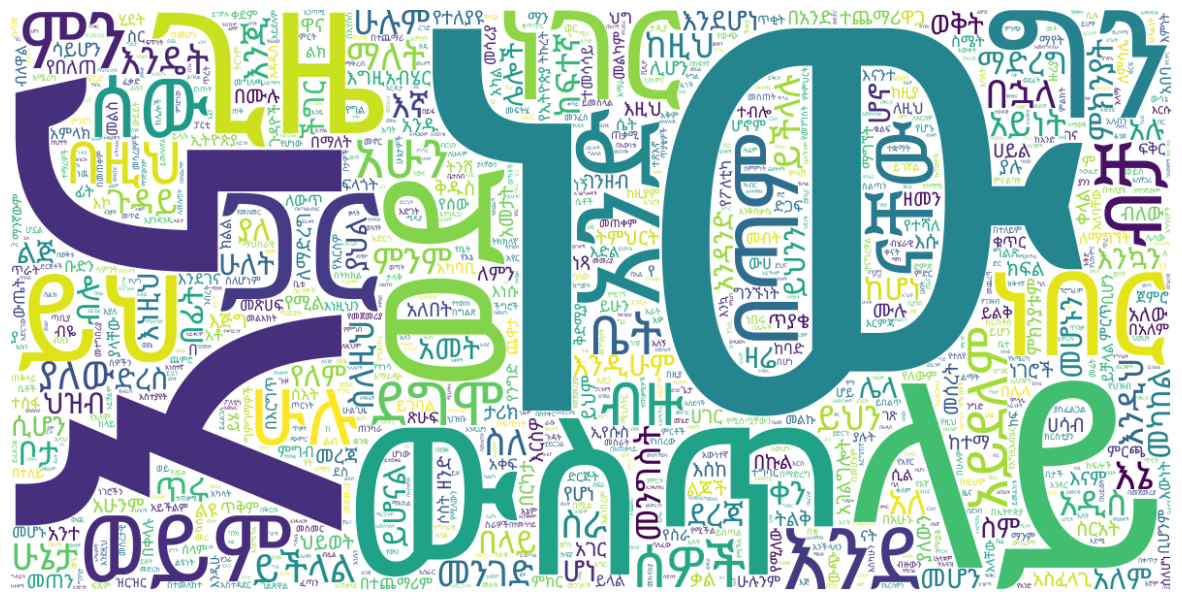

In [15]:
# get the top 1000 most frequent words
top_words = dict(list(word_frequencies.items())[:1000])
wordcloud = WordCloud(
    font_path=FONT_PATH,
    width=1200,
    height=600,
    max_words=len(top_words),
    background_color="white",
).generate_from_frequencies(top_words)

# i want the image to be high resolution
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### **Loading and Training the Tokenizer**

In [7]:
# Load the data
data = load_dataset("text", data_files=DATA_PATH, split="train")
data

Dataset({
    features: ['text'],
    num_rows: 6406258
})

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

In [ ]:
# Train a new tokenizer
amh_tokenizer = tokenizer.train_new_from_iterator(data["text"], vocab_size=50000)

In [ ]:
# Check the vocab size
amh_tokens = list(amh_tokenizer.get_vocab().keys())
len(amh_tokens)

50000

In [9]:
len(tokenizer)

128256

In [ ]:
# amh_tokenizer = tokenizer.train_new_from_iterator(data["text"], vocab_size=len(tokenizer))
# amh_tokens = list(amh_tokenizer.get_vocab().keys())
# len(amh_tokens)

for amh_token in amh_tokens:
    print(f'"{amh_tokenizer.convert_tokens_to_string([amh_token])}"', end=", ")

" ስላገኘሁ", " በዚያኛው", " ማንኛቸውም", " ስንጥቅ", " ከቤቷ", " ተብያለሁ", " ዘለቁ", " የሚባሉትም", " አይጠጡ", " አጥብ", "ያኔ", "የህዝቡ", " መወራ", "ድነቅ", " ቢደረግ", " የራስዋ", "ከጉባኤው", "መምህሩም", "ፍታታ", " ለማደር", "ካበት", "ጡራ", "ጨጌ", " መስፈን", "ዝቃዜና", "ሰለስቱ", "ቀመስ", " አቀላጥ", "የአሸዋ", " እንዳ", " እንደሚጠብቅ", "ጽፍ",  " የሚታሰብ", " ግሪካዊ", "ኗታል", "ጠበቀውን", " አመጣ", " ገንዘብም", "ሊቀመንበሩ", "ሎቻችሁን", "ፈት", " ከዶ", " አትቀበሉ", " ሰሙነ", "ኩሌር", 

In [49]:
print(list(amh_tokens)[:20])

['áĭ¨áĬ¢áĬ®áĬĸáĪļ', 'Ġáĭ¨áĬłáĭŃáĪģáĭµ', 'Ġáĭ¨áĪĢáī¥áĪ¨áī°áĪ°áī¥', 'áĭ¨áĪµ', 'ĠáĪĺáĮĪáĭ°áĪį', 'áĪĢáĪĭáįĬáĬĲáīµ', 'áĬ®áĪŃ', 'áĪĭáīĢ', 'ĠáĪµáĪ«áĭİáī½', 'ĠáĪµáĪĽ', 'ĠáĪĽáĪĪáīµ', 'ĠáĬķáĮ¥áĪ¨áĬĲáĮĪáĪ®áī½', 'ĠáĬłáĭ«áīµ', 'ĠáĬłáĭŃáĮĪáĪŃ', 'ĠáĪĿáĪ¨áĮ¡', 'Ġáī°áĪ°áĪŃáī·áĪį', 'ĠáĬ«áĪĿáįķ', 'Ġáĭ¨áĪĬáīĢ', 'áīłáīĥáĬķ', 'Ġáĭ¨áĪĽáĮŃáīłáĪŃáīłáĪŃ']


In [ ]:
for amh_token in amh_tokens:
    print(f'"{amh_tokenizer.convert_tokens_to_string([amh_token])}"', end=", ")

In [ ]:
for id in reversed(range(45000, 50000)):
    amh_str = amh_tokenizer.convert_tokens_to_string(
        [amh_tokenizer.convert_ids_to_tokens(id)]
    )
    print(f'"{amh_str}": {id}', end=", ")

"ምላኬ": 49999, "ገጠማቸው": 49998, " የየራሱ": 49997, "ከወነ": 49996, " አስታጥ": 49995, " መንጋውን": 49994, " ፈላጊው": 49993, " ከኤች": 49992, " ይጠቁሙ": 49991, " ማህበረሰባችን": 49990, " የቻር": 49989, " የቆየሁት": 49988, " ተሳታፊዎችን": 49987, "ሞተሩ": 49986, " ማምከን": 49985, " በፊልሙ": 49984, " ለጥናት": 49983, " ቤተሰቦቼን": 49982, " አዲሳባ": 49981, " ተመርምሮ": 49980, " የሚኖርባት": 49979, " ከአንደኛው": 49978, " ትግስት": 49977, " እድገታቸውን": 49976, " የባለድርሻ": 49975, "ምድራዊ": 49974, " ተደፍቶ": 49973, " ኢትዮጵያውያንና": 49972, "ገዙም": 49971, " መዘገቡ": 49970, " የሚፈሩት": 49969, " ተነሳስተው": 49968, "ከፊሉ": 49967, " አወያይ": 49966, " ኮንሶ": 49965, " ታማኞች": 49964, " ሰምታ": 49963, "ረገጠ": 49962, " ኦሮሚያን": 49961, " ፍሬድ": 49960, " መልእክታቸው": 49959, " አመሰገነ": 49958, " ጥበቃዎች": 49957, " ግዴለም": 49956, "ኔትዎርክ": 49955, "ጠላቶች": 49954, "ንጉር": 49953, "ከረች": 49952, " አያስከትልም": 49951, " የፈሰሰው": 49950, "ጀምሩም": 49949, " በመስጋት": 49948, "ተናቸዋል": 49947, " ፖሊስም": 49946, "ፈራሪያ": 49945, " ተወረ": 49944, " ተጽፈው": 49943, " አላማውም": 49942, "ፍራፊ": 49941, " አልተሰማም": 49940, " በኢስላም": 49939, " እንደተሰጣ

In [ ]:
for amh_token in amh_tokens:
    print(
        f'"{amh_tokenizer.convert_tokens_to_string([amh_token])}": {amh_tokenizer.convert_tokens_to_ids(amh_token)}',
        end=", ",
    )

In [ ]:
amh_tokenizer.save_pretrained(f"{TOKENIZER_PATH}/{NEW_TOKENIZER_ID}")

('C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-50k\\tokenizer_config.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-50k\\special_tokens_map.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-50k\\tokenizer.json')

In [ ]:
amh_tokenizer.save_pretrained(f"{TOKENIZER_PATH}/Llama-3.2-3B-bnb-4bit-amh-128k")

('C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-128k\\tokenizer_config.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-128k\\special_tokens_map.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-128k\\tokenizer.json')

In [ ]:
amh_tokenizer.push_to_hub("Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-128k", private=True)

tokenizer.json:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-128k/commit/fb2ff8c99f35bdacf0c246aae4abe0d35cd5f42f', commit_message='Upload tokenizer', commit_description='', oid='fb2ff8c99f35bdacf0c246aae4abe0d35cd5f42f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-128k', endpoint='https://huggingface.co', repo_type='model', repo_id='Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-128k'), pr_revision=None, pr_num=None)

### **Merging Trained Tokenizer**

In [88]:
tokenizer.add_tokens(amh_tokens)

50000

In [ ]:
len(tokenizer)

177741

In [ ]:
tokenizer.save_pretrained(f"{TOKENIZER_PATH}/Llama-3.2-3B-bnb-4bit-amh-merged-178k")

('C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-merged-178k\\tokenizer_config.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-merged-178k\\special_tokens_map.json',
 'C:/dev/Projects/Local-LLM-Llama3/assets/tokenizers/Llama-3.2-3B-bnb-4bit-amh-merged-178k\\tokenizer.json')

In [ ]:
tokenizer.push_to_hub(
    "Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-merged-178k", private=True
)
amh_tokenizer.push_to_hub("Naod-Demissie/Llama-3.2-3B-bnb-4bit-amh-50k", private=True)